# QME: Numerical Solution

We solve the master equation numerically using QuTiP package.  Here is the master equation again. 

$$
\frac{d}{dt} \rho = -\frac{i}{\hbar} \left[H_\text{rwa},\rho\right]+ \mathcal{D}(\rho)
$$

with 

$$
H_\text{rwa} = \frac{\hbar}{2}{\Delta} \sigma_{3} + \frac{\hbar}{2} \Omega \sigma_{1}
$$

and


$$
\mathcal{D}(\rho) = \gamma_{0} (N+1) \left(\sigma_{-}\rho\sigma_{+} - \frac{1}{2} \sigma_{+}\sigma_{-}\rho - \frac{1}{2} \rho \sigma_{+}\sigma_{-} \right)\\+\gamma_{0} N \left(\sigma_{+}\rho\sigma_{-} - \frac{1}{2} \sigma_{-}\sigma_{+}\rho - \frac{1}{2} \rho \sigma_{-}\sigma_{+\\} \right)
$$

The difference from the numerical calculation in {numref}`sec:qme` is only the presence of the driving term. Hence, we just modify the previous code.  Try different values for $\Delta$ and $\Omega$.

## Time evolution of density operator


The difference from the numerical calculation in {numref}`sec:qme` is only the presence of the driving term. Hence, we just modify the previous code.  Try different values for $\Delta$ and $\Omega$.

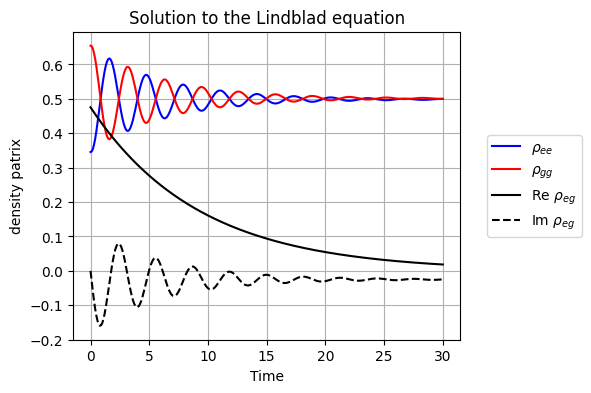

In [1]:
# ignore warnings (qutip issues various unwanted warnings)
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
omega0 = 1.0
Delta = 0.0   # detuning
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
Omega = 2.0 # Rabi frequency
N = 1/(np.exp(omega0/temperature)-1) # Planck distribution
theta = 2*np.pi/10 # initial condition

gamma1 = gamma0 * N   # coefficient to absorption
gamma2 = gamma0 * (N+1)  # coefficient to emission
gamma = gamma1+gamma2

# Hamiltonian for a two-level system (in the rotating frame)
H = 0.5 * Delta * sigmaz() + 0.5 * Omega * sigmax()

# Jump operators
c_ops = [np.sqrt(gamma1) * sigmap(),np.sqrt(gamma2) * sigmam()]

# Initial state: start in the ground state |g>
psi0 = basis(2,0)*np.sin(theta) + basis(2,1)*np.cos(theta)

# evaluation time
times = np.linspace(0, 30, 300)

# observables to compute
observables = [sigmax(),sigmay(),sigmaz()]

# solve the Lindblad Equation
result = mesolve(H, psi0, times, c_ops, observables)

# Construct the density matrix from the results
r_list = []
k=len(result.expect[0])
i=0
s0 = np.eye(2,2)
s1 = np.array([[0,1],[1,0]])
s2 = np.array([[0,-1j],[1j,0]])
s3 = np.array([[1,0],[0,-1]])
while i<k:
    r = (s0+result.expect[0][i]*s1+result.expect[1][i]*s2+result.expect[2][i]*s3)/2
    r_list.append(r)
    i += 1
    
rho = np.array(r_list)  # density matrix as a function of time

# 4. Plotting the Time Evolution
plt.figure(figsize=(5, 4))
plt.plot(times,rho[:,0,0].real, label=r"$\rho_{ee}$",c='b')
plt.plot(times,rho[:,1,1].real, label=r"$\rho_{gg}$",c='r')
plt.plot(times,rho[:,0,1].real, label=r"Re $\rho_{eg}$",c='k')
plt.plot(times,rho[:,0,1].imag, label=r"Im $\rho_{eg}$",c='k',linestyle='--')
plt.title("Solution to the Lindblad equation")
plt.xlabel("Time")
plt.ylabel("density patrix")
plt.legend(bbox_to_anchor=(1.05, 0.5),loc="center left")
plt.grid(True)
plt.show()

## The second order coherence

We can use the same code as given in {numref}`sec:qme`. The coherence vanishes at $\tau=0$ as expected for the emission from a single TLS.  Notice the Rabi oscillation around the dip caused by the driving.

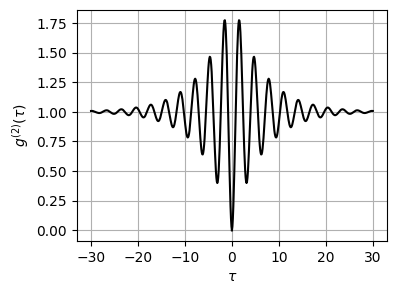

In [2]:
# Continued from the previous code block. 
# You need to execute it before running this code.

g2, G2 = coherence_function_g2(H, None, times, c_ops, sigmam())
plt.figure(figsize=(4,3))
plt.plot(times, np.real(g2),c='k')
plt.plot(-times,np.real(g2), c='k')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.grid(True)
plt.show()